**Neural networks for road segmentation**
========================

Your next task is to train neural network to segment road on images from car cams.

The original dataset is provided by Karlsruhe Institute of Technology (http://www.cvlibs.net/datasets/kitti/eval_road.php). Their images are ±370x1270, but, for simlictiy, we will use 370x370 squares.

One can download the dataset from https://disk.yandex.ru/d/QPOw4hk84-se_w

Here is an example of input data with corresponding ground truth:

In [47]:
import os
import cv2
import numpy as np

import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
%matplotlib inline

In [48]:
def get_paths(path):
    _, _, filenames = next(os.walk(path))

    images_paths = []
    for filename in sorted(filenames):            
        images_paths.append(os.path.join(path, filename))
    
    return np.stack(images_paths)

class RoadDataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, images, masks, transform, aug=None,):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform
        self.aug = aug
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):        
        im_name = self.images[idx]
        mask_name = self.masks[idx]
        
        image = cv2.imread(im_name)[:,:,::-1] / 255.0  # ::-1 to convert from BGR to RGB
        mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        
        if self.aug:
            sample = self.aug(
                image=image,
                mask=mask,
            )
        else:
            sample = {
                'image': image,
                'mask': mask,
            }
        
        sample['image'] = self.transform(sample['image']).float()
        sample['mask'] = self.transform(sample['mask']).float()

        return sample['image'], sample['mask']

In [3]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

transform = transforms.Compose([
    transforms.ToTensor(),
])

In [4]:
train_dataset = RoadDataset(X_train, y_train, transform)

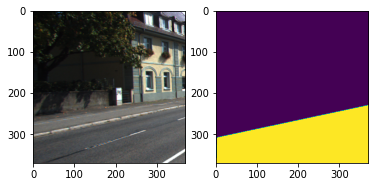

In [5]:
sample = train_dataset[110]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))

Workflow:
---
* Choose correct loss function, write training loop and code for testing. Feel free to use previous HW for inspiration. 
* Train any segmentation neural network from scratch (for example U-Net) and achieve >= 0.75 IoU on test set (40% points). See function to calculate the metric below.
* Use any pretrained model for image classification, convert it for segmentation by adding decoder (don't forget skip-connections) or usign dilated convolutions and achieve >= 0.87 IoU  on test set (60% points).

You're not allowed to do only one thing: train your network on test set.

----
Your final solution will consist of an ipython notebook with code (for final networks training + any experiments with data) and test metric calculation.

Feel free to ask in Telegram chat if something is not clear :3


In [6]:
print(f"Dataset length {len(train_dataset)}")

Dataset length 648


Dataset is small so actively use data augmentation: rotations, flip, color-change etc. to prevent overfitting.

Most likely you'll have to pad your images to 512x512 (it divides by 2^5=32, like U-Net wants). Use PadIfNeeded from Albumentations and central crop (see below) after prediction to calculate loss/metrics (you don't want to pay attention on padded values).

----
There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for the "road" class, or add class weights in optimized loss. You also can try to use softIoU or DICE loss.

In [49]:
import albumentations as alb

Good luck!

In [50]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

X_test = get_paths("data/test/images")
y_test = get_paths("data/test/gt")

In [81]:
a_train = alb.Compose([
    alb.PadIfNeeded(min_height=512, min_width=512),
    alb.HorizontalFlip(),
    alb.Rotate(30),
])

a_test = alb.Compose([
    alb.PadIfNeeded(min_height=512, min_width=512)
])

In [82]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
])

In [83]:
train_dataset = RoadDataset(X_train, y_train, transform_train, aug=a_train)
test_dataset = RoadDataset(X_test, y_test, transform_test, aug=a_test)

In [8]:
from torch import nn

In [54]:
class UNetConvBlock(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.block = nn.Sequential(
                        nn.Conv2d(in_channels=input_dim, out_channels=output_dim, kernel_size=3, padding='same'),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=output_dim, out_channels=output_dim, kernel_size=3, padding='same'),
                        nn.ReLU())

    def forward(self, x):
        return self.block(x)
                

In [10]:
class CustomUNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv_enc1 = UNetConvBlock(3, 64)
        
        self.pool1 = nn.MaxPool2d(2)     
        self.conv_enc2 = UNetConvBlock(64, 128)
        
        self.pool2 = nn.MaxPool2d(2)        
        self.conv_enc3 = UNetConvBlock(128, 256)
        
        self.pool3 = nn.MaxPool2d(2)        
        self.conv_enc4 = UNetConvBlock(256, 512)
        
        self.pool4 = nn.MaxPool2d(2)        
        self.conv_enc5 = UNetConvBlock(512, 1024)
        
        self.up1 = nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=2, stride=2)
        self.conv_dec1 = UNetConvBlock(1024, 512)
        
        self.up2 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)
        self.conv_dec2 = UNetConvBlock(512, 256)
        
        self.up3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.conv_dec3 = UNetConvBlock(256, 128)
        
        self.up4 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.conv_dec4 = UNetConvBlock(128, 64)
        
        self.final_conv = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=3, padding='same')

    def forward(self, x):
        x1 = self.conv_enc1(x)
        x2 = self.conv_enc2(self.pool1(x1))
        x3 = self.conv_enc3(self.pool2(x2))
        x4 = self.conv_enc4(self.pool3(x3))
        x5 = self.conv_enc5(self.pool4(x4))
        
        u1 = self.conv_dec1(torch.cat([self.up1(x5), x4], dim=1))
        u2 = self.conv_dec2(torch.cat([self.up2(u1), x3], dim=1))
        u3 = self.conv_dec3(torch.cat([self.up3(u2), x2], dim=1))
        u4 = self.conv_dec4(torch.cat([self.up4(u3), x1], dim=1))
    
        return self.final_conv(u4)


In [11]:
torch.cuda.empty_cache()

In [55]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=True)

In [56]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum() 
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) , union

In [119]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    images = images[:, :, border_len:current_size-border_len, border_len:current_size-border_len]
    return images

In [58]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [59]:
device

'cuda'

In [17]:
model = CustomUNet().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss(reduction='none')

In [68]:
import torch.nn.functional as F

EPOCHS_NUM = 30
IMG_SIZE = 370

In [ ]:
from tqdm.auto import tqdm 

for epoch_num in range(EPOCHS_NUM):
    sum_loss = 0
    cnt = 0
    for batch_x, batch_y in tqdm(train_dataloader):
        opt.zero_grad()       
        batch_x, batch_y = batch_x.to(device), batch_y.to(device, int)        
        out = model(batch_x)
        central_crop(out, IMG_SIZE)
        central_crop(batch_y, IMG_SIZE)
        loss = criterion(out, batch_y.squeeze(1)).sum()
        sum_loss += loss.item()
        cnt += 1
        loss.backward()
        opt.step()
        
    print(f'Epoch {epoch_num + 1}. Loss: {sum_loss / cnt / 64 }')    
        
    if (epoch_num + 1) % 5 == 0:
        with torch.no_grad():
            sum_i, sum_u = 0, 0
            for batch_x, batch_y in tqdm(test_dataloader):
                batch_x, batch_y = batch_x.to(device), batch_y.to(device, int)
                prediction = F.softmax(model(batch_x), dim=1).argmax(dim=1).unsqueeze(1)
                central_crop(prediction, IMG_SIZE)
                central_crop(batch_y, IMG_SIZE)
                curr_i, curr_u = calc_iou(prediction.cpu().numpy(), batch_y.cpu().numpy())
                sum_i += curr_i
                sum_u += curr_u

            print(f'Epoch {epoch_num + 1}. IoU: {sum_i / sum_u}')    

            
            

            
        
        

100%|██████████| 81/81 [00:15<00:00,  5.34it/s]


Epoch 1. Loss: 4568.978759765625


100%|██████████| 81/81 [00:15<00:00,  5.31it/s]


Epoch 2. Loss: 4513.237063560957


100%|██████████| 81/81 [00:15<00:00,  5.30it/s]


...

Epoch 29. Loss: 4120.833927107446


100%|██████████| 81/81 [00:15<00:00,  5.32it/s]


Epoch 30. Loss: 4016.34656213831


100%|██████████| 28/28 [00:04<00:00,  6.84it/s]

Epoch 30. IoU: 0.7676885703261573


сюдааааааааааааааа

строго говоря мнее понадобилось 90 эпох, я цикл 3 раза пускал

## Часть 2

In [62]:
import torch
from torch import nn
from torchvision.models import resnet18
from torchvision.models.resnet import ResNet, BasicBlock, ResNet18_Weights

In [71]:
class ResNet18Encoder(ResNet):
    def __init__(self):
        super().__init__(BasicBlock, [2, 2, 2, 2])
        
    def forward(self, x):
        x1 = self.conv1(x)
        x1 = self.bn1(x1)
        x1 = self.relu(x1)
        
        x2 = self.maxpool(x1)
        x2 = self.layer1(x2)

        x3 = self.layer2(x2)

        x4 = self.layer3(x3)

        x5 = self.layer4(x4)

        return x, x1, x2, x3, x4, x5    

In [72]:
class ResNet18Segmentator(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.encoder = ResNet18Encoder()
        self.encoder.load_state_dict(ResNet18_Weights.DEFAULT.get_state_dict(progress=True))
        
        self.up1 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)
        self.conv_dec1 = UNetConvBlock(512, 256)
        
        self.up2 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.conv_dec2 = UNetConvBlock(256, 128)
        
        self.up3 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.conv_dec3 = UNetConvBlock(128, 64)
        
        self.up4 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=2, stride=2)
        self.conv_dec4 = UNetConvBlock(96, 48)
        
        self.up5 = nn.ConvTranspose2d(in_channels=48, out_channels=24, kernel_size=2, stride=2)
        
        self.final_conv = nn.Conv2d(in_channels=27, out_channels=num_classes, kernel_size=3, padding='same')

    def forward(self, x):
        x, x1, x2, x3, x4, x5 = self.encoder(x)      # 512, 256, 128, 64, 32, 16    3, 64, 64, 128, 256, 512
        
        
        u1 = self.conv_dec1(torch.cat([self.up1(x5), x4], dim=1)) #u1 -> [, 256, 32, 32]
        u2 = self.conv_dec2(torch.cat([self.up2(u1), x3], dim=1)) #u2 -> [, 128, 64, 64]
        u3 = self.conv_dec3(torch.cat([self.up3(u2), x2], dim=1)) #u3 -> [, 64, 128, 128]
        u4 = self.conv_dec4(torch.cat([self.up4(u3), x1], dim=1))
        u5 = self.final_conv(torch.cat([self.up5(u4), x], dim=1))

        return u5

In [157]:
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=True)

In [142]:
model2 = ResNet18Segmentator().to(device)
opt = torch.optim.AdamW(model2.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss(reduction='none')

In [143]:
from tqdm.auto import tqdm 

for epoch_num in range(EPOCHS_NUM):
    sum_loss = 0
    cnt = 0
    for batch_x, batch_y in tqdm(train_dataloader):
        opt.zero_grad()       
        batch_x, batch_y = batch_x.to(device), batch_y.to(device, int)        
        out = model2(batch_x)
        out = central_crop(out, IMG_SIZE)
        batch_y = central_crop(batch_y, IMG_SIZE)
        loss = criterion(out, batch_y.squeeze(1)).sum()
        sum_loss += loss.item()
        cnt += 1
        loss.backward()
        opt.step()
        
    print(f'Epoch {epoch_num + 1}. Loss: {sum_loss / cnt / 64 }')    
        
    if (epoch_num + 1) % 5 == 0:
        with torch.no_grad():
            sum_i, sum_u = 0, 0
            for batch_x, batch_y in tqdm(test_dataloader):
                batch_x, batch_y = batch_x.to(device), batch_y.to(device, int)
                prediction = F.softmax(model2(batch_x), dim=1).argmax(dim=1).unsqueeze(1)
                prediction = central_crop(prediction, IMG_SIZE)
                batch_y = central_crop(batch_y, IMG_SIZE)
                curr_i, curr_u = calc_iou(prediction.cpu().numpy(), batch_y.cpu().numpy())
                sum_i += curr_i
                sum_u += curr_u

            print(f'Epoch {epoch_num + 1}. IoU: {sum_i / sum_u}')    



100%|██████████| 81/81 [00:21<00:00,  3.84it/s]


Epoch 1. Loss: 10995.006172839507


100%|██████████| 81/81 [00:21<00:00,  3.81it/s]


Epoch 2. Loss: 7152.66271520544


100%|██████████| 81/81 [00:21<00:00,  3.78it/s]


...

Epoch 29. Loss: 672.9252726236979


100%|██████████| 81/81 [00:22<00:00,  3.66it/s]


Epoch 30. Loss: 652.3544187192564


100%|██████████| 28/28 [00:05<00:00,  5.25it/s]

Epoch 30. IoU: 0.8710079800418992


In [144]:
from tqdm.auto import tqdm 

for epoch_num in range(EPOCHS_NUM):
    sum_loss = 0
    cnt = 0
    for batch_x, batch_y in tqdm(train_dataloader):
        opt.zero_grad()       
        batch_x, batch_y = batch_x.to(device), batch_y.to(device, int)        
        out = model2(batch_x)
        out = central_crop(out, IMG_SIZE)
        batch_y = central_crop(batch_y, IMG_SIZE)
        loss = criterion(out, batch_y.squeeze(1)).sum()
        sum_loss += loss.item()
        cnt += 1
        loss.backward()
        opt.step()
        
    print(f'Epoch {epoch_num + 1}. Loss: {sum_loss / cnt / 64 }')    
        
    if (epoch_num + 31) % 5 == 0:
        with torch.no_grad():
            sum_i, sum_u = 0, 0
            for batch_x, batch_y in tqdm(test_dataloader):
                batch_x, batch_y = batch_x.to(device), batch_y.to(device, int)
                prediction = F.softmax(model2(batch_x), dim=1).argmax(dim=1).unsqueeze(1)
                prediction = central_crop(prediction, IMG_SIZE)
                batch_y = central_crop(batch_y, IMG_SIZE)
                curr_i, curr_u = calc_iou(prediction.cpu().numpy(), batch_y.cpu().numpy())
                sum_i += curr_i
                sum_u += curr_u

            print(f'Epoch {epoch_num + 1}. IoU: {sum_i / sum_u}')    



100%|██████████| 81/81 [00:21<00:00,  3.71it/s]


Epoch 1. Loss: 668.4815466610002


100%|██████████| 81/81 [00:21<00:00,  3.70it/s]


Epoch 2. Loss: 654.9077728648244


100%|██████████| 81/81 [00:21<00:00,  3.69it/s]


...

Epoch 5. Loss: 609.787941261574


100%|██████████| 28/28 [00:05<00:00,  5.24it/s]


Epoch 5. IoU: 0.8766554040020472


 77%|███████▋  | 62/81 [00:17<00:05,  3.64it/s]


KeyboardInterrupt: 

In [155]:
image, mask = test_dataset[110]

img_shw = central_crop(image.unsqueeze(0), 370)

inp = image.unsqueeze(0)

out = model2(inp.cuda())

out = central_crop(out, 370)
out = out.squeeze(0).cpu().detach()

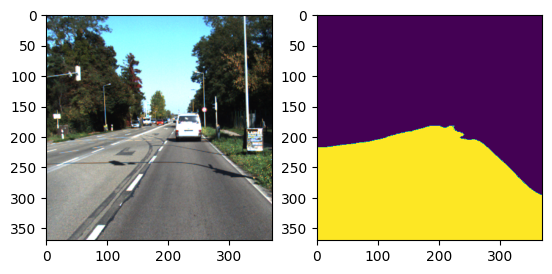

In [156]:
plt.subplot(1, 2, 1)
plt.imshow(img_shw.squeeze(0).permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(out.argmax(dim=0))